In [1]:
import kagglehub
import cv2
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Sequential,Model
import random

In [ ]:
!pip install -q kaggle

import os

os.environ["KAGGLE_API_TOKEN"] = "you_api_key"

!kaggle datasets download -d joe1995/div2k-dataset

!unzip -q /content/div2k-dataset.zip

!ls

Dataset URL: https://www.kaggle.com/datasets/joe1995/div2k-dataset
License(s): unknown
100% 3.71G/3.71G [03:11<00:00, 20.8MB/s]

div2k-dataset.zip  DIV2K_train_HR  DIV2K_valid_HR  sample_data


In [3]:
PATCH = 128            # size of each training piece
PATCHES_PER_IMAGE = 10
BATCH = 16
STEPS_PER_EPOCH = 200
EPOCHS = 10
FACTORS = [2, 4, 8]   # pixel strength

In [4]:
train_dir = Path("/content/DIV2K_train_HR/DIV2K_train_HR")
valid_dir = Path("/content/DIV2K_valid_HR/DIV2K_valid_HR")
train_paths = sorted(train_dir.glob("*.png"))
valid_paths = sorted(valid_dir.glob("*.png"))
print("Train images:", len(train_paths))
print("Valid images:", len(valid_paths))

Train images: 800
Valid images: 100


In [5]:
def read_image(path):
    img = cv2.imread(str(path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img.astype(np.float32) / 255.0

In [6]:
def random_patch(img, size=PATCH):
    h, w, _ = img.shape
    y = np.random.randint(0, h - size + 1)
    x = np.random.randint(0, w - size + 1)
    return img[y:y + size, x:x + size]

In [7]:
def pixelate(img, factor=None):
    if factor is None:
        factor = int(np.random.choice(FACTORS))
    h, w = img.shape[:2]
    small = cv2.resize(img, (w // factor, h // factor),
                       interpolation=cv2.INTER_AREA)
    return cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)

In [8]:
def show_images(images, titles):
    plt.figure(figsize=(6 * len(images), 6))
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(np.clip(img, 0, 1))
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [9]:
def augment(img):
    if random.random() < 0.5:
        img = img[:, ::-1]
    if random.random() < 0.5:
        img = img[::-1]
    img = np.rot90(img, random.randint(0, 3))
    return np.ascontiguousarray(img)

In [10]:
def data_generator():
    while True:
        paths = train_paths.copy()
        random.shuffle(paths)
        for p in paths:
            img = read_image(p)
            for _ in range(PATCHES_PER_IMAGE):
                patch = augment(random_patch(img))
                yield pixelate(patch), patch

In [11]:
spec = tf.TensorSpec(shape=(PATCH, PATCH, 3), dtype=tf.float32)

dataset = (
    tf.data.Dataset.from_generator(data_generator, output_signature=(spec, spec))
    .shuffle(64)
    .batch(BATCH)
    .prefetch(tf.data.AUTOTUNE)
)

In [12]:
# small fixed validation set
val_x, val_y = [], []
for p in valid_paths[:40]:
    img = read_image(p)
    for _ in range(2):
        patch = random_patch(img)
        val_x.append(pixelate(patch))
        val_y.append(patch)
val_x = np.array(val_x)
val_y = np.array(val_y)
print("Validation:", val_x.shape)

Validation: (80, 128, 128, 3)


Batch shapes: (16, 128, 128, 3) (16, 128, 128, 3)


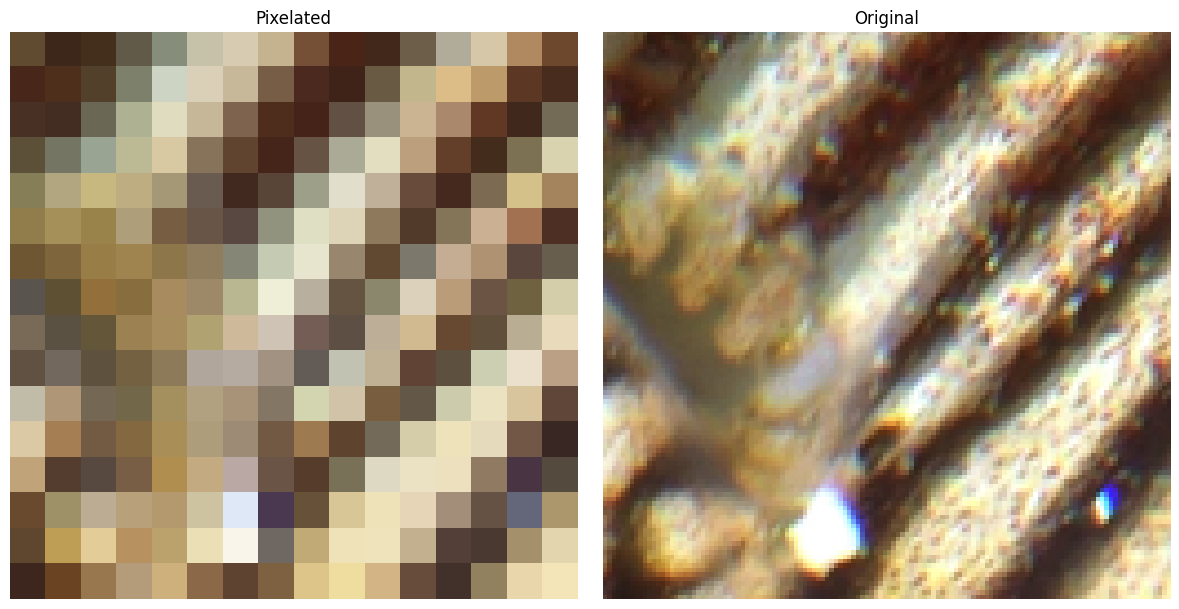

In [13]:
# quick check
for x_batch, y_batch in dataset.take(1):
    print("Batch shapes:", x_batch.shape, y_batch.shape)
    show_images([x_batch[0].numpy(), y_batch[0].numpy()],
                ["Pixelated", "Original"])

In [14]:
def res_block(x, filters):
    shortcut = layers.Conv2D(filters, 1, padding="same")(x)
    y = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    y = layers.Conv2D(filters, 3, padding="same")(y)
    y = layers.Add()([shortcut, y])
    return layers.ReLU()(y)


def build_unet():
    inputs = layers.Input(shape=(None, None, 3))

    e1 = res_block(inputs, 32)
    p1 = layers.MaxPooling2D(2)(e1)
    e2 = res_block(p1, 64)
    p2 = layers.MaxPooling2D(2)(e2)
    e3 = res_block(p2, 128)
    p3 = layers.MaxPooling2D(2)(e3)
    e4 = res_block(p3, 256)
    p4 = layers.MaxPooling2D(2)(e4)

    b = res_block(p4, 256)

    u4 = layers.UpSampling2D(2)(b)
    d4 = res_block(layers.Concatenate()([u4, e4]), 256)
    u3 = layers.UpSampling2D(2)(d4)
    d3 = res_block(layers.Concatenate()([u3, e3]), 128)
    u2 = layers.UpSampling2D(2)(d3)
    d2 = res_block(layers.Concatenate()([u2, e2]), 64)
    u1 = layers.UpSampling2D(2)(d2)
    d1 = res_block(layers.Concatenate()([u1, e1]), 32)

    # model learns only the correction, then adds it to the input
    correction = layers.Conv2D(3, 3, padding="same", dtype="float32")(d1)
    outputs = layers.Add(dtype="float32")([inputs, correction])
    return Model(inputs, outputs)


def l1_ssim_loss(y_true, y_pred):
    l1 = tf.reduce_mean(tf.abs(y_true - y_pred))
    ssim = tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))
    return l1 + 0.1 * (1.0 - ssim)


def psnr(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 0.0, 1.0)
    return tf.reduce_mean(tf.image.psnr(y_true, y_pred, max_val=1.0))


model = build_unet()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
    loss=l1_ssim_loss,
    metrics=[psnr],
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, None,      │        896 │ input_layer[0][0] │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, None,      │        128 │ input_layer[0][0] │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, None,      │      9,248 │ conv2d_1[0][0]    │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, None,      │          0 │ conv2d[0][0],     │
│                     │ None, 32)         │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, None,      │          0 │ add[0][0]         │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, None,      │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, None,      │     18,496 │ max_pooling2d[0]… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, None,      │      2,112 │ max_pooling2d[0]… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, None,      │     36,928 │ conv2d_4[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, None,      │          0 │ conv2d_3[0][0],   │
│                     │ None, 64)         │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, None,      │          0 │ add_1[0][0]       │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, None,      │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, None,      │     73,856 │ max_pooling2d_1[… │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, None,      │      8,320 │ max_pooling2d_1[… │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, None,      │    147,584 │ conv2d_7[0][0]    │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, None,      │          0 │ conv2d_6[0][0], 

 Total params: 5,203,299 (19.85 MB)

 Trainable params: 5,203,299 (19.85 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
EPOCHS = 50
STEPS_PER_EPOCH = 200

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/best_model.keras",
        monitor="val_loss",
        save_best_only=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=8, restore_best_weights=True
    ),
]

history = model.fit(
    dataset,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=(val_x, val_y),
    callbacks=callbacks,
)

model.save("/content/last_model.keras")
print("Saved.")

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 81s 267ms/step - loss: 0.0595 - psnr: 28.7726 - val_loss: 0.0542 - val_psnr: 29.7549 - learning_rate: 2.0000e-04
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 42s 212ms/step - loss: 0.0608 - psnr: 29.1128 - val_loss: 0.0525 - val_psnr: 30.2244 - learning_rate: 2.0000e-04
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 41s 206ms/step - loss: 0.0539 - psnr: 30.2007 - val_loss: 0.0507 - val_psnr: 30.5992 - learning_rate: 2.0000e-04
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 40s 202ms/step - loss: 0.0527 - psnr: 30.4408 - val_loss: 0.0492 - val_psnr: 30.9445 - learning_rate: 2.0000e-04
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 40s 201ms/step - loss: 0.0520 - psnr: 30.7768 - val_loss: 0.0495 - val_psnr: 31.1264 - learning_rate: 2.0000e-04
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 46s 229ms/step - loss: 0.0521 - psnr: 30.4848 - val_loss: 0.0477 - val_psnr: 31.5453 - learning_rate: 2.0000e-04
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 41s 203ms/step - loss: 0.0489 - psnr: 31.1

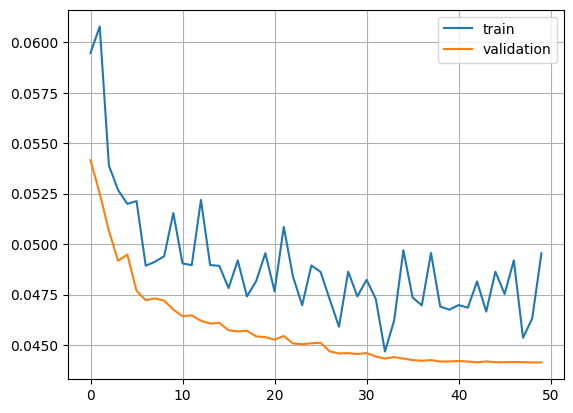

In [17]:
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.legend()
plt.grid(True)
plt.show()

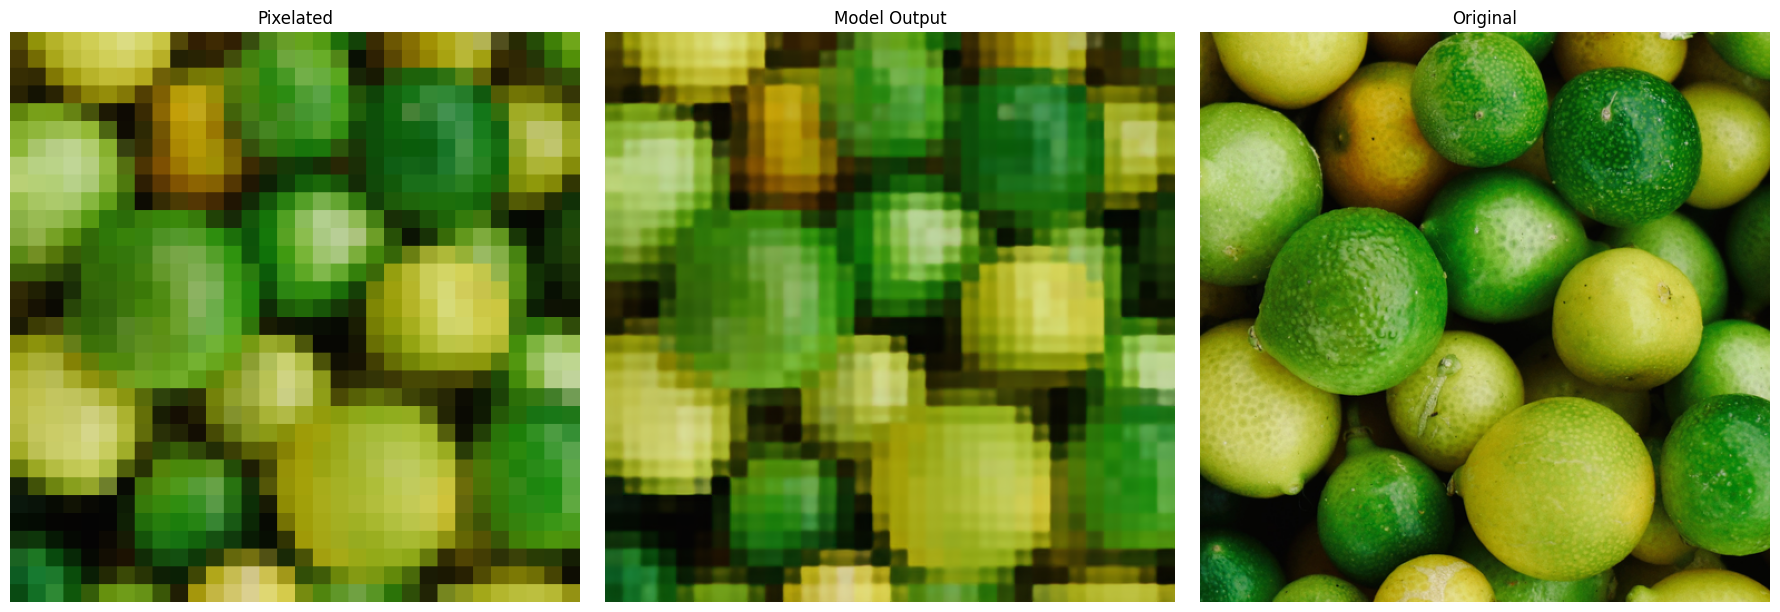

In [18]:
# Optional: load the saved model
# model = tf.keras.models.load_model("/content/best_model.keras", compile=False)

def predict_image(model, img):
    # size must be divisible by 4, so pad first
    h, w, _ = img.shape
    pad_h = (4 - h % 4) % 4
    pad_w = (4 - w % 4) % 4
    padded = np.pad(img, ((0, pad_h), (0, pad_w), (0, 0)), mode="reflect")
    out = model.predict(padded[None, ...], verbose=0)[0]
    return np.clip(out[:h, :w], 0, 1)


IMAGE_NUMBER = 1
TEST_SIZE = 512

original = read_image(valid_paths[IMAGE_NUMBER])

# center crop so it fits in memory
h, w, _ = original.shape
top = max(0, (h - TEST_SIZE) // 2)
left = max(0, (w - TEST_SIZE) // 2)
original = original[top:top + TEST_SIZE, left:left + TEST_SIZE]

pixelated = pixelate(original, factor=16)
result = predict_image(model, pixelated)

show_images([pixelated, result, original],
            ["Pixelated", "Model Output", "Original"])

In [19]:
import pandas as pd

NUM_IMAGES = 20        # how many test images
EVAL_SIZE = 512        # crop size
EVAL_FACTORS = [2, 4, 8]

In [20]:
def center_crop(img, size):
    h, w, _ = img.shape
    size = min(size, h, w)
    top = (h - size) // 2
    left = (w - size) // 2
    return img[top:top + size, left:left + size]

In [21]:
def predict_image(model, img):
    h, w, _ = img.shape
    pad_h = (4 - h % 4) % 4
    pad_w = (4 - w % 4) % 4
    padded = np.pad(img, ((0, pad_h), (0, pad_w), (0, 0)), mode="reflect")
    out = model.predict(padded[None, ...], verbose=0)[0]
    return np.clip(out[:h, :w], 0, 1)

In [22]:
def all_metrics(target, pred):
    t = tf.convert_to_tensor(target[None, ...], tf.float32)
    p = tf.convert_to_tensor(pred[None, ...], tf.float32)

    mse = float(tf.reduce_mean(tf.square(t - p)))
    mae = float(tf.reduce_mean(tf.abs(t - p)))
    rmse = float(np.sqrt(mse))
    psnr = float(tf.image.psnr(t, p, max_val=1.0)[0])
    ssim = float(tf.image.ssim(t, p, max_val=1.0)[0])

    try:
        ms_ssim = float(tf.image.ssim_multiscale(t, p, max_val=1.0)[0])
    except Exception:
        ms_ssim = np.nan

    return {"MSE": mse, "MAE": mae, "RMSE": rmse,
            "PSNR": psnr, "SSIM": ssim, "MS-SSIM": ms_ssim}

In [23]:
rows = []
for path in valid_paths[:NUM_IMAGES]:
    original = center_crop(read_image(path), EVAL_SIZE)

    for factor in EVAL_FACTORS:
        pixelated = pixelate(original, factor=factor)
        result = predict_image(model, pixelated)

        before = all_metrics(original, pixelated)
        after = all_metrics(original, result)

        rows.append({"Factor": factor, "Type": "Pixelated", **before})
        rows.append({"Factor": factor, "Type": "Model", **after})


In [24]:
df = pd.DataFrame(rows)
summary = df.groupby(["Factor", "Type"]).mean(numeric_only=True).round(4)
print(summary)

                     MSE     MAE    RMSE     PSNR    SSIM  MS-SSIM
Factor Type                                                       
2      Model      0.0009  0.0158  0.0261  32.8738  0.9214   0.9958
       Pixelated  0.0016  0.0214  0.0369  29.2700  0.8742   0.9939
4      Model      0.0025  0.0279  0.0464  27.4316  0.7775   0.9563
       Pixelated  0.0038  0.0346  0.0586  25.0706  0.6887   0.9346
8      Model      0.0048  0.0405  0.0658  24.1268  0.6250   0.8589
       Pixelated  0.0065  0.0484  0.0783  22.4076  0.5330   0.8015


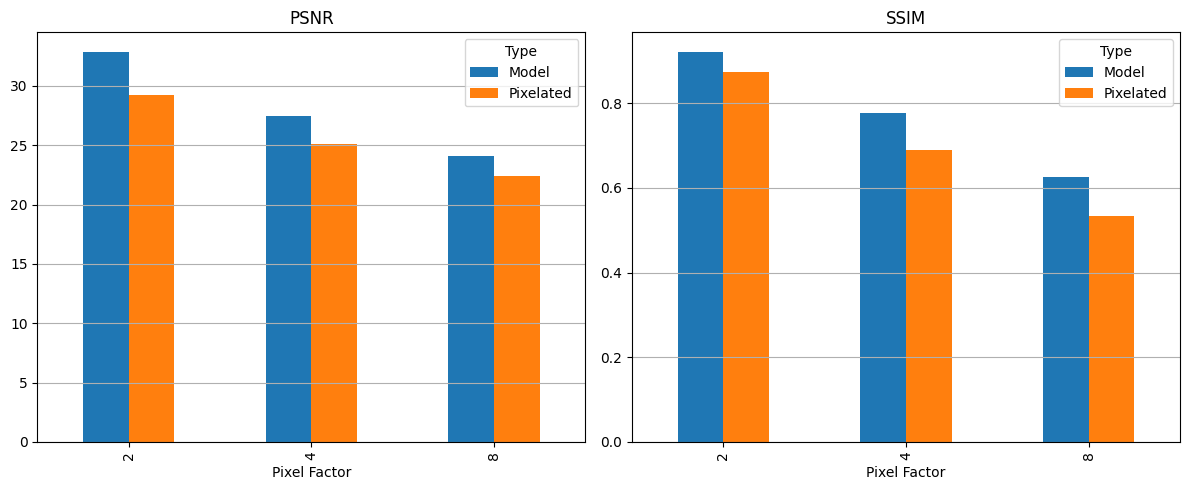

In [25]:
# Plot PSNR and SSIM
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, metric in zip(axes, ["PSNR", "SSIM"]):
    table = df.groupby(["Factor", "Type"])[metric].mean().unstack()
    table.plot(kind="bar", ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("Pixel Factor")
    ax.grid(True, axis="y")
plt.tight_layout()
plt.show()